<a href="https://colab.research.google.com/github/parthmavani/CODSOFT/blob/main/Credit_Card_Fraud_Detection/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df = pd.read_csv("creditcard.csv")


df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103088 entries, 0 to 103087
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    103088 non-null  int64  
 1   V1      103088 non-null  float64
 2   V2      103088 non-null  float64
 3   V3      103088 non-null  float64
 4   V4      103088 non-null  float64
 5   V5      103088 non-null  float64
 6   V6      103088 non-null  float64
 7   V7      103088 non-null  float64
 8   V8      103088 non-null  float64
 9   V9      103088 non-null  float64
 10  V10     103088 non-null  float64
 11  V11     103088 non-null  float64
 12  V12     103088 non-null  float64
 13  V13     103088 non-null  float64
 14  V14     103088 non-null  float64
 15  V15     103088 non-null  float64
 16  V16     103088 non-null  float64
 17  V17     103088 non-null  float64
 18  V18     103088 non-null  float64
 19  V19     103088 non-null  float64
 20  V20     103088 non-null  float64
 21  V21     10

In [ ]:
# Check missing values

print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [ ]:


df = df.dropna()

In [ ]:


print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


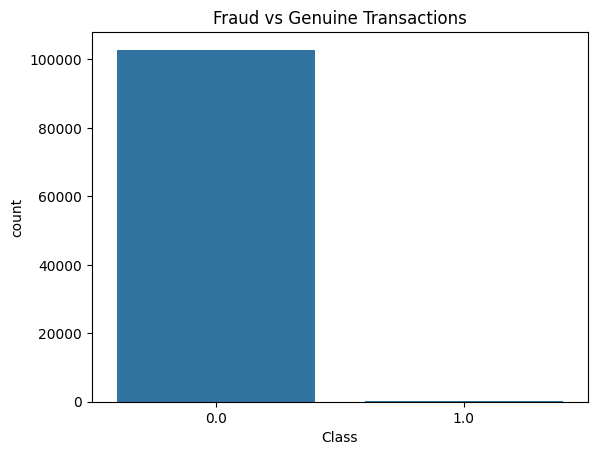

In [ ]:
# Fraud vs Genuine transactions graph

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Genuine Transactions")

plt.show()

In [ ]:
# Count transactions

print(df["Class"].value_counts())

Class
0.0    102855
1.0       232
Name: count, dtype: int64


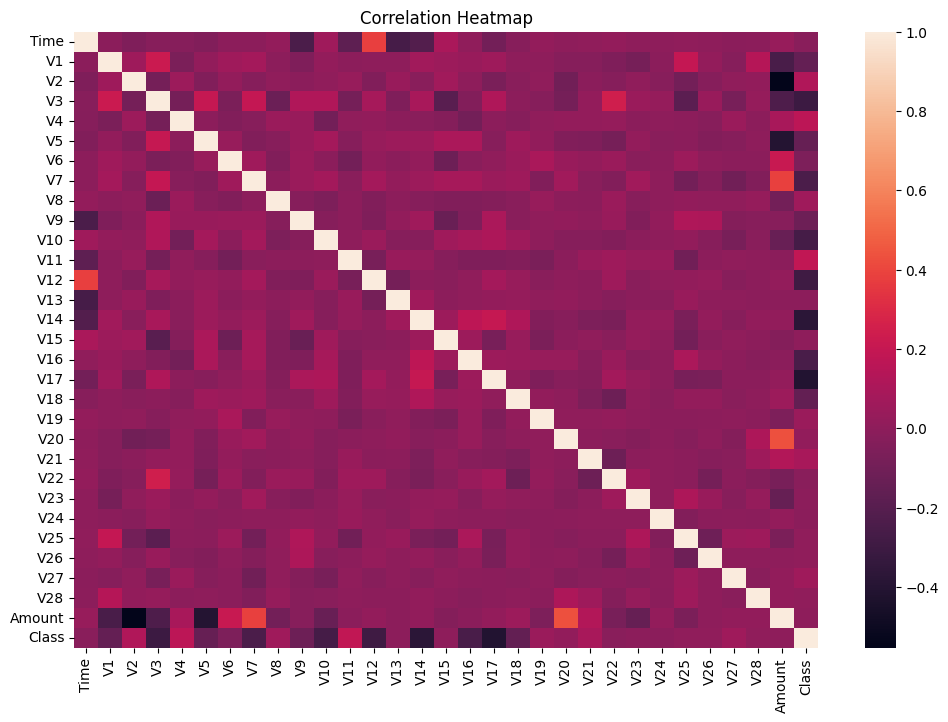

In [ ]:


plt.figure(figsize=(12,8))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")

plt.show()

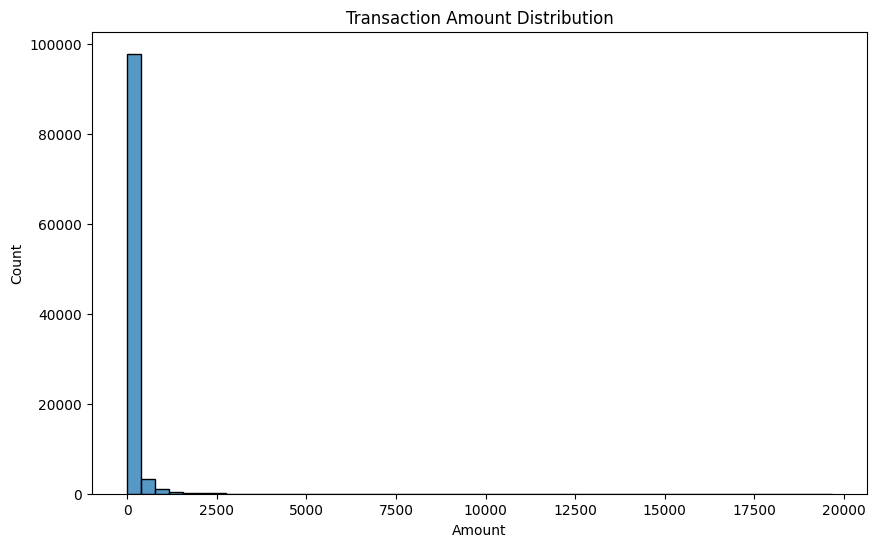

In [ ]:


plt.figure(figsize=(10,6))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

In [ ]:


X = df.drop("Class", axis=1)



y = df["Class"]

In [ ]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:


from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:


y_pred = model.predict(X_test)

print(y_pred)

[0. 0. 0. ... 0. 0. 0.]


In [ ]:
# Accuracy score

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 99.94%


In [ ]:
# Classification report

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     20565
         1.0       0.98      0.77      0.86        53

    accuracy                           1.00     20618
   macro avg       0.99      0.89      0.93     20618
weighted avg       1.00      1.00      1.00     20618



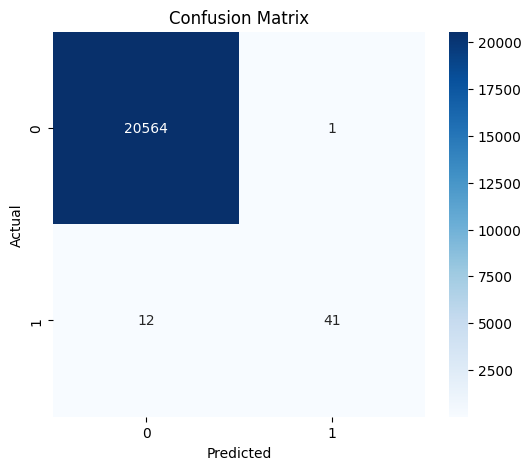

In [ ]:
# Confusion matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Conclusion

This project detects fraudulent credit card transactions using Machine Learning techniques.

The Random Forest Classifier model was used to classify transactions as genuine or fraudulent based on transaction details.

Different visualizations and evaluation metrics such as accuracy, precision, recall, F1-score, and confusion matrix were used to analyze the model performance.

This project helped in understanding fraud detection systems and classification problems using Machine Learning.